# Evaluation Method, Baseline and Pretrained Model

With the data prepared, the next step is to decide how every model will be evaluated and to measure two approaches that need no training on our data. The first is a TF-IDF baseline, which matches questions and answers through the words they share. The second is a pretrained sentence-embedding model, `multi-qa-MiniLM-L6-cos-v1`, used without any changes. Together they show how far simple word matching and general-purpose embeddings can go before a model is fine-tuned in the next notebook.

## How the Models Are Evaluated

Every model is evaluated in the same way. The knowledge base contains every unique cleaned answer from the training, validation and test sets, 1,205 answers in total, which is exactly what the web app searches. For each validation or test question, the model ranks all 1,205 answers by cosine similarity, and we record the position of the question's own human-written answer. Three metrics summarise these positions.

| Metric | Meaning |
|---|---|
| Recall@1 | The share of questions whose correct answer is ranked first, which is the answer the user would see. |
| Recall@3 | The share of questions whose correct answer is among the top three. |
| MRR | The mean reciprocal rank, the average of 1 divided by the rank of the correct answer. A value of 1.0 means the correct answer is always first, and 0.5 means it is second on average. |

The question is compared with the answers rather than with the dataset questions for a practical reason. Each validation and test question is itself stored in the dataset, so matching it against dataset questions would simply find its own copy and produce a perfect score. Matching against answers avoids this problem, and it is also the task the pretrained model was designed for, since its model card reports training on 215 million question and answer pairs. In addition to the validation and test sets, we report results on 40 paraphrased questions stored in `data/probes/paraphrases.csv`. These are validation and test questions reworded in everyday English. They are used only for evaluation, never for training.

In [1]:
# Work from the repository root so that `src` can be imported and the data paths resolve.
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import numpy as np
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

from src.config import BASE_MODEL, PROCESSED_DIR
from src.retrieval import TfidfRetriever, EmbeddingRetriever, load_knowledge_base
from src.evaluation import run_experiment, experiments_table

kb = load_knowledge_base()
answers = kb.answer.tolist()
val = pd.read_csv(PROCESSED_DIR / "val.csv")
print("knowledge-base answers:", len(kb))

knowledge-base answers: 1205


## Building the TF-IDF Baseline (E1)

TF-IDF turns each text into a long vector with one weight for every word or pair of words (bigram) in its vocabulary. A term's weight grows when it appears often in the text (term frequency) and shrinks when it is common across all answers (inverse document frequency), so a rare word such as *nitazoxanide* counts for more than a common word such as *Africa*. English stop words are removed, and the question vector is compared with each answer vector using cosine similarity, which is 1 when two vectors point in the same direction and 0 when the texts share no terms. The method is simple and easy to explain, but it has no notion of meaning, so *fever* and *pyrexia* are completely unrelated words to it.

In [2]:
tfidf = TfidfRetriever(answers)
print("vocabulary (unigrams + bigrams):", len(tfidf.vectorizer.vocabulary_))
example = val.question.iloc[3]
scores = tfidf.scores([example])[0]
top = scores.argsort()[::-1][:3]
print("QUESTION:", example)
pd.DataFrame({"cosine": scores[top].round(3), "answer": kb.answer.iloc[top].str[:110].values,
              "is its own answer": kb.answer.iloc[top].values == val.answer.iloc[3]})

vocabulary (unigrams + bigrams): 30081
QUESTION: What are common traditional remedies for treating skin infections in Africa?


,cosine,answer,is its own answer
0,0.337,"Management of skin infections in Africa may involve basic hygiene practices, topical medications, and traditio",False
1,0.288,"Plant-based remedies like aloe vera, neem, and baobab oil are commonly used for treating skin infections in Af",True
2,0.280,"Shea butter, aloe vera, and coconut oil are commonly used traditional remedies for treating various skin condi",False


The example shows how the baseline behaves in practice. For a question about traditional remedies for skin infections, the correct answer is ranked second, just behind an answer about the management of skin infections that shares many of the same words.

In [3]:
e1 = run_experiment("E1_tfidf", tfidf, kb, "Baseline: TF-IDF (unigrams+bigrams, English stop-words removed) + cosine similarity",
                    method="tfidf", model="", index="answers")
pd.DataFrame({s: e1[s] for s in ["val", "test", "paraphrase"]}).T

,recall@1,recall@3,mrr,questions
val,0.5532,0.7092,0.6564,141.0
test,0.2373,0.3249,0.2941,354.0
paraphrase,0.0750,0.2500,0.2113,40.0


The baseline ranks the correct answer first for 55.3% of validation questions, but only for 23.7% of test questions and 7.5% of paraphrased questions. The low paraphrase score is expected, because rewording a question removes most of the words it shares with its answer.

## Using Pretrained Sentence Embeddings (E2)

The pretrained model represents meaning rather than word overlap, and it turns a text into a vector in three steps. First, a tokenizer splits the text into WordPiece tokens, breaking unfamiliar medical words into smaller known pieces. Next, a six-layer Transformer with the BERT architecture (MiniLM) turns each token into a 384-number vector that depends on the whole sentence, because self-attention allows every token to take every other token into account. Finally, the token vectors are averaged (mean pooling) and scaled to length 1, which gives one 384-number sentence embedding. Texts with similar meanings end up with similar embeddings even when they share no words, and the next cell shows these steps for one example question.

In [4]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(BASE_MODEL, device="cpu")
print(model)
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}", "| max tokens:", model.max_seq_length)
text = "How can someone know they may have malaria?"
print("tokens:", model.tokenizer.tokenize(text))
vector = model.encode(text, normalize_embeddings=True)
print("embedding shape:", vector.shape, "| length:", round(float(np.linalg.norm(vector)), 3), "| first 6 numbers:", vector[:6].round(3))

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)
parameters: 22,713,216 | max tokens: 512
tokens: ['how', 'can', 'someone', 'know', 'they', 'may', 'have', 'malaria', '?']
embedding shape: (384,) | length: 1.0 | first 6 numbers: [ 0.058  0.017  0.013  0.006  0.109 -0.008]


The model has 22.7 million parameters and accepts up to 512 tokens. The example question is split into ordinary word tokens, and its embedding is a vector of 384 numbers with a length of exactly 1, which means that the cosine similarity between two embeddings is simply their dot product.

## Comparing TF-IDF and Embeddings on Paraphrases

To see the difference between the two representations directly, we compare the same pairs of sentences with both methods. The first three pairs have similar meanings, while the last pair is unrelated.

In [5]:
pairs = [("What are the symptoms of malaria?", "How can someone know they may have malaria?"),
         ("What are the symptoms of malaria?", "What are the signs of a fever caused by mosquito parasites?"),
         ("What is the leading cause of neonatal mortality in Nigeria?", "What kills the most newborn babies in Nigeria?"),
         ("What are the symptoms of malaria?", "How do I repair my laptop?")]
rows = []
for a, b in pairs:
    t = TfidfRetriever([b]).scores([a])[0][0]      # Fitting TF-IDF on one sentence is enough for this illustration.
    va, vb = model.encode([a, b], normalize_embeddings=True)
    rows.append({"sentence A": a, "sentence B": b, "TF-IDF cosine": round(float(t), 3), "embedding cosine": round(float(va @ vb), 3)})
pd.DataFrame(rows)

,sentence A,sentence B,TF-IDF cosine,embedding cosine
0,What are the symptoms of malaria?,How can someone know they may have malaria?,0.577,0.796
1,What are the symptoms of malaria?,What are the signs of a fever caused by mosquito parasites?,0.000,0.699
2,What is the leading cause of neonatal mortality in Nigeria?,What kills the most newborn babies in Nigeria?,0.378,0.735
3,What are the symptoms of malaria?,How do I repair my laptop?,0.000,0.150


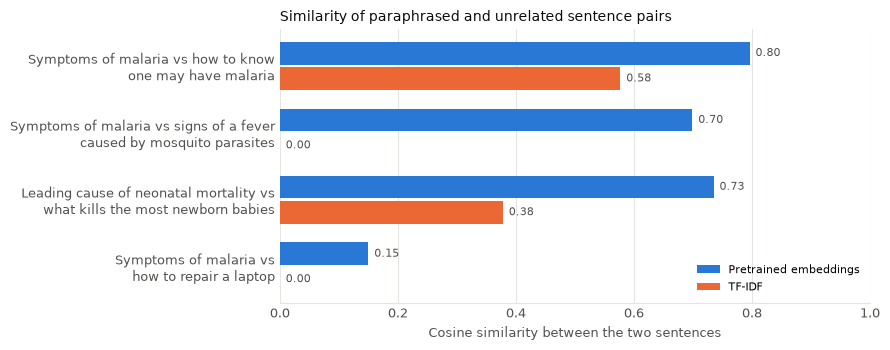

In [6]:
import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, YELLOW, LIGHT = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

def tidy(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left" if grid_axis == "x" else "top"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)

# The same four sentence pairs as a chart.
from src.config import FIGURES_DIR
sim = pd.DataFrame(rows)
labels = ["Symptoms of malaria vs how to know\none may have malaria",
          "Symptoms of malaria vs signs of a fever\ncaused by mosquito parasites",
          "Leading cause of neonatal mortality vs\nwhat kills the most newborn babies",
          "Symptoms of malaria vs\nhow to repair a laptop"]
y = np.arange(len(sim))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(y - 0.19, sim["embedding cosine"], height=0.34, color=BLUE, label="Pretrained embeddings")
ax.barh(y + 0.19, sim["TF-IDF cosine"], height=0.34, color=ORANGE, label="TF-IDF")
for k, (e, t) in enumerate(zip(sim["embedding cosine"], sim["TF-IDF cosine"])):
    ax.text(e + 0.01, k - 0.19, f"{e:.2f}", va="center", fontsize=8, color=INK2)
    ax.text(t + 0.01, k + 0.19, f"{t:.2f}", va="center", fontsize=8, color=INK2)
ax.set_yticks(y, labels, fontsize=8); ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_xlabel("Cosine similarity between the two sentences", fontsize=9, color=INK2)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.set_title("Similarity of paraphrased and unrelated sentence pairs", loc="left", fontsize=10, color=INK)
tidy(ax, "x")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "similarity_pairs.png", dpi=200); plt.show()

The second pair shows the difference most clearly. "What are the symptoms of malaria?" and "What are the signs of a fever caused by mosquito parasites?" share no important words, so TF-IDF gives them a similarity of 0.000, whereas the embedding model gives 0.699. The unrelated laptop question receives an embedding similarity of only 0.150, which suggests that embedding scores could also help the assistant recognise questions it should not answer.

## Matching Questions With Answers

Retrieval compares a question with every answer, not with one sentence, so it helps to look at several questions and answers at once. The heatmap below uses the pretrained model to compare six validation questions (rows) with their six human-written answers (columns). A good retrieval model gives the highest value in each row to the answer on the diagonal, which is also exactly what fine-tuning in notebook 03 trains the model to do.

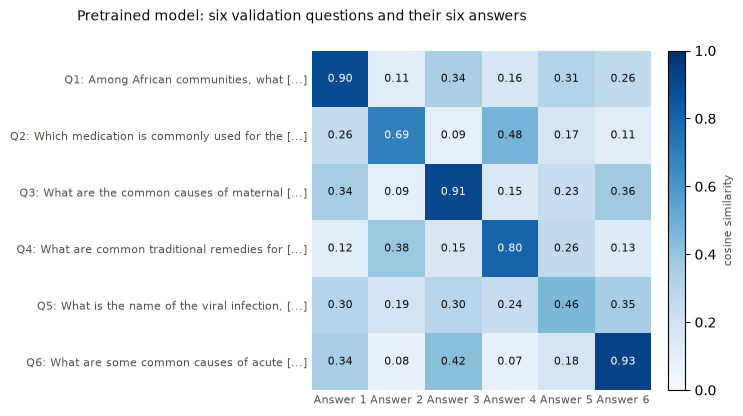

rows where the question's own answer has the highest similarity: 6 of 6
margin over the best other answer per row: [0.56 0.21 0.55 0.42 0.11 0.5 ]


In [7]:
# Similarity between six validation questions and their own answers, computed with the pretrained model.
import textwrap
sample = val.head(6)
qv = model.encode(sample.question.tolist(), normalize_embeddings=True)
av = model.encode(sample.answer.tolist(), normalize_embeddings=True)
matrix = qv @ av.T
fig, ax = plt.subplots(figsize=(9, 4.2))
image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
for r in range(6):
    for c in range(6):
        ax.text(c, r, f"{matrix[r, c]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if matrix[r, c] > 0.6 else INK)
ax.set_xticks(range(6), [f"Answer {c + 1}" for c in range(6)], fontsize=8)
ax.set_yticks(range(6), [f"Q{r + 1}: {textwrap.shorten(q, 48)}" for r, q in enumerate(sample.question)], fontsize=8)
ax.tick_params(length=0, colors=INK2)
for side in ax.spines.values():
    side.set_visible(False)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02).set_label("cosine similarity", fontsize=8, color=INK2)
fig.suptitle("Pretrained model: six validation questions and their six answers", fontsize=10, color=INK)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "qa_similarity_heatmap.png", dpi=200); plt.show()
print("rows where the question's own answer has the highest similarity:", int((matrix.argmax(axis=1) == np.arange(6)).sum()), "of 6")
# The margin is the own answer's similarity minus the best other answer in the same row.
others = np.where(np.eye(6, dtype=bool), -1, matrix).max(axis=1)
print("margin over the best other answer per row:", np.round(np.diag(matrix) - others, 2))

For all six questions the highest value in the row is the question's own answer, so even without any training the pretrained model places the correct answer first in this small sample. The margins are not equal, however. Questions 1, 3 and 6 are clearly separated from the other answers, while question 5 about a viral infection gives its own answer only 0.46, which is 0.11 above the next answer. Small margins like this one become a real problem when the correct answer has to beat 1,204 other answers instead of five, which is why the full evaluation below gives much lower scores than this sample suggests.

In [8]:
e2 = run_experiment("E2_pretrained", EmbeddingRetriever(model, answers), kb,
                    "Pretrained multi-qa-MiniLM-L6-cos-v1 embeddings, no fine-tuning",
                    method="embedding", model=BASE_MODEL, index="answers")
experiments_table(["E1_tfidf", "E2_pretrained"]).drop(columns="description").round(3)

,name,val_recall@1,val_recall@3,val_mrr,test_recall@1,test_recall@3,test_mrr,paraphrase_recall@1,paraphrase_recall@3,paraphrase_mrr
0,E1_tfidf,0.553,0.709,0.656,0.237,0.325,0.294,0.075,0.25,0.211
1,E2_pretrained,0.624,0.794,0.711,0.316,0.424,0.388,0.475,0.60,0.552


## Comparing the Two Approaches

The pretrained model performed better than TF-IDF on every set, without any training on our data. Validation Recall@1 rose from 0.553 to 0.624 and test Recall@1 from 0.237 to 0.316. The largest gain was on the paraphrased questions, where Recall@1 rose from 0.075 to 0.475, which confirms what the sentence pairs above suggested: TF-IDF works only when the user repeats the words of the dataset.

Both methods, however, lost much of their accuracy between the validation and test sets. The validation questions come from the same crowdsourced source as the training data, and their answers usually repeat the question's words. The test questions are expert exam prompts such as "Complications of thyroidectomy", whose answers are short lists that share little vocabulary with the prompt, so they are much harder to match. The word repetition in the crowdsourced answers also flatters the TF-IDF result on the validation set, which makes the baseline stronger than it might first appear.

These results give a clear starting point for the next notebook, where the pretrained model is fine-tuned on the 711 training pairs to see whether adapting it to AfriMed-QA improves on E2.